# BAN6800 — BA-09: Compare Classifiers with Cross-Validation

**Project:** AI-Enabled Predictive and Prescriptive Analytics for Marine Asset Maintenance and Operational Availability at Chairborne Global Services Limited (CGSL)

**Purpose:** Compare Logistic Regression, Random Forest, and Gradient Boosting using stratified cross-validation on the validated BA-07 training feature set.

### Experimental controls
- The official UCI test set is **not used** for model comparison or tuning.
- Five-fold `StratifiedKFold` cross-validation is performed on the training data.
- The same folds are used for all candidate models.
- Logistic Regression uses scaling inside a pipeline.
- Class imbalance is explicitly addressed for Logistic Regression and Random Forest with class weights.
- Gradient Boosting uses balanced sample weights in each training fold.
- Threshold remains **0.50**; threshold optimization is reserved for BA-10.
- Primary metrics: Precision, Recall, F1-score, and ROC-AUC.


In [1]:
# BA-09 — Setup

import os
import json
import warnings
from io import BytesIO

import requests
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPLITS = 5
BASELINE_THRESHOLD = 0.50

print("BA-09 libraries loaded successfully.")


BA-09 libraries loaded successfully.


## 1. Load the validated BA-07 feature artifacts

The final BA-07 representation contains 60,000 training observations and 334 features. The large NumPy arrays are stored in Git LFS, so the actual LFS objects are retrieved from GitHub's media endpoint.


In [2]:
TRAIN_FEATURE_URL = "https://media.githubusercontent.com/media/dvfekorigha-create/BAN6800-cgsl-predictive-maintenance/main/data/processed/X_train_final.npy"
TEST_FEATURE_URL = "https://media.githubusercontent.com/media/dvfekorigha-create/BAN6800-cgsl-predictive-maintenance/main/data/processed/X_test_final.npy"
Y_TRAIN_URL = "https://raw.githubusercontent.com/dvfekorigha-create/BAN6800-cgsl-predictive-maintenance/main/data/processed/y_train.csv"
Y_TEST_URL = "https://raw.githubusercontent.com/dvfekorigha-create/BAN6800-cgsl-predictive-maintenance/main/data/processed/y_test.csv"

def load_npy_from_url(url, label):
    response = requests.get(url, timeout=180)
    response.raise_for_status()
    print(f"{label}: {len(response.content)/1024**2:.1f} MB downloaded")
    return np.load(BytesIO(response.content), allow_pickle=False)

X_train = load_npy_from_url(TRAIN_FEATURE_URL, "X_train_final")
X_test = load_npy_from_url(TEST_FEATURE_URL, "X_test_final")

y_train = pd.read_csv(Y_TRAIN_URL).squeeze("columns")
y_test = pd.read_csv(Y_TEST_URL).squeeze("columns")

print("Training feature shape:", X_train.shape)
print("Test feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Test target shape:", y_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())


X_train_final: 152.9 MB downloaded
X_test_final: 40.8 MB downloaded
Training feature shape: (60000, 334)
Test feature shape: (16000, 334)
Training target shape: (60000,)
Test target shape: (16000,)

Training target distribution:
class
neg    59000
pos     1000
Name: count, dtype: int64


In [3]:
# Integrity checks

assert X_train.shape == (60000, 334), f"Unexpected X_train shape: {X_train.shape}"
assert X_test.shape == (16000, 334), f"Unexpected X_test shape: {X_test.shape}"
assert len(y_train) == 60000
assert len(y_test) == 16000
assert np.isfinite(X_train).all()
assert np.isfinite(X_test).all()
assert set(y_train.unique()) == {"neg", "pos"}

print("BA-09 input integrity checks passed.")


BA-09 input integrity checks passed.


## 2. Define candidate classifiers

The comparison uses the established Logistic Regression baseline plus two nonlinear tree ensembles. This is a comparison stage rather than extensive hyperparameter tuning; detailed threshold and cost-sensitive optimization is reserved for BA-10.


In [4]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            solver="lbfgs",
            max_iter=500,
            random_state=RANDOM_STATE,
        )),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        min_samples_leaf=2,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=75,
        learning_rate=0.05,
        max_depth=2,
        subsample=0.8,
        random_state=RANDOM_STATE,
    ),
}

for name in models:
    print("-", name)


- Logistic Regression
- Random Forest
- Gradient Boosting


## 3. Five-fold stratified cross-validation

The same five stratified folds are used for every classifier. For each fold, the model is fitted on the training portion and evaluated on the held-out portion. No official test-set observations are used.


In [6]:
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

fold_results = []
confusion_matrices = {}

for model_name, estimator in models.items():
    print(f"\n===== {model_name} =====")
    model_fold_cms = []

    for fold_number, (train_idx, valid_idx) in enumerate(
        cv.split(X_train, y_train), start=1
    ):
        X_fit = X_train[train_idx]
        X_valid = X_train[valid_idx]
        y_fit = y_train.iloc[train_idx].to_numpy()
        y_valid = y_train.iloc[valid_idx].to_numpy()

        if model_name == "Gradient Boosting":
            sample_weight = compute_sample_weight(
                class_weight="balanced",
                y=y_fit
            )
            estimator.fit(
                X_fit,
                y_fit,
                sample_weight=sample_weight
            )
        else:
            estimator.fit(X_fit, y_fit)

        y_pred = estimator.predict(X_valid)

        classes = list(estimator.classes_)
        pos_index = classes.index("pos")
        y_prob = estimator.predict_proba(X_valid)[:, pos_index]

        precision = precision_score(
            y_valid, y_pred, pos_label="pos", zero_division=0
        )
        recall = recall_score(
            y_valid, y_pred, pos_label="pos", zero_division=0
        )
        f1 = f1_score(
            y_valid, y_pred, pos_label="pos", zero_division=0
        )
        roc_auc = roc_auc_score(
            (y_valid == "pos").astype(int),
            y_prob
        )

        cm = confusion_matrix(
            y_valid,
            y_pred,
            labels=["neg", "pos"]
        )

        model_fold_cms.append(cm)

        fold_results.append({
            "Model": model_name,
            "Fold": fold_number,
            "Precision": precision,
            "Recall": recall,
            "F1_Score": f1,
            "ROC_AUC": roc_auc,
            "True_Negatives": int(cm[0, 0]),
            "False_Positives": int(cm[0, 1]),
            "False_Negatives": int(cm[1, 0]),
            "True_Positives": int(cm[1, 1]),
        })

        print(
            f"Fold {fold_number}/{N_SPLITS} completed | "
            f"F1={f1:.4f} | Recall={recall:.4f} | ROC-AUC={roc_auc:.4f}"
        )

    confusion_matrices[model_name] = model_fold_cms

fold_results_df = pd.DataFrame(fold_results)

print("\nCross-validation completed successfully.")
print("Fold-model evaluations:", len(fold_results_df))
display(fold_results_df)


===== Logistic Regression =====
Fold 1/5 completed | F1=0.5287 | Recall=0.9200 | ROC-AUC=0.9670
Fold 2/5 completed | F1=0.5145 | Recall=0.8900 | ROC-AUC=0.9665
Fold 3/5 completed | F1=0.5257 | Recall=0.9450 | ROC-AUC=0.9804
Fold 4/5 completed | F1=0.5066 | Recall=0.8650 | ROC-AUC=0.9375
Fold 5/5 completed | F1=0.5353 | Recall=0.9300 | ROC-AUC=0.9733

===== Random Forest =====
Fold 1/5 completed | F1=0.7853 | Recall=0.6950 | ROC-AUC=0.9922
Fold 2/5 completed | F1=0.7855 | Recall=0.7050 | ROC-AUC=0.9818
Fold 3/5 completed | F1=0.7289 | Recall=0.6250 | ROC-AUC=0.9875
Fold 4/5 completed | F1=0.7500 | Recall=0.6600 | ROC-AUC=0.9833
Fold 5/5 completed | F1=0.7087 | Recall=0.5900 | ROC-AUC=0.9867

===== Gradient Boosting =====
Fold 1/5 completed | F1=0.3948 | Recall=0.9800 | ROC-AUC=0.9907
Fold 2/5 completed | F1=0.3831 | Recall=0.9500 | ROC-AUC=0.9788
Fold 3/5 completed | F1=0.3778 | Recall=0.9550 | ROC-AUC=0.9823
Fold 4/5 completed | F1=0.3947 | Recall=0.9600 | ROC-AUC=0.9844
Fold 5/5 comp

,Model,Fold,Precision,Recall,F1_Score,ROC_AUC,True_Negatives,False_Positives,False_Negatives,True_Positives
0,Logistic Regression,1,0.370968,0.920,0.528736,0.967008,11488,312,16,184
1,Logistic Regression,2,0.361789,0.890,0.514451,0.966525,11486,314,22,178
2,Logistic Regression,3,0.364162,0.945,0.525730,0.980351,11470,330,11,189
3,Logistic Regression,4,0.358178,0.865,0.506589,0.937463,11490,310,27,173
4,Logistic Regression,5,0.375758,0.930,0.535252,0.973292,11491,309,14,186
5,Random Forest,1,0.902597,0.695,0.785311,0.992236,11785,15,61,139
6,Random Forest,2,0.886792,0.705,0.785515,0.981832,11782,18,59,141
7,Random Forest,3,0.874126,0.625,0.728863,0.987545,11782,18,75,125
8,Random Forest,4,0.868421,0.660,0.750000,0.983294,11780,20,68,132
9,Random Forest,5,0.887218,0.590,0.708709,0.986742,11785,15,82,118


In [7]:
# Summarize cross-validation performance

cv_summary = (
    fold_results_df
    .groupby("Model")
    .agg(
        Precision_Mean=("Precision", "mean"),
        Precision_SD=("Precision", "std"),
        Recall_Mean=("Recall", "mean"),
        Recall_SD=("Recall", "std"),
        F1_Mean=("F1_Score", "mean"),
        F1_SD=("F1_Score", "std"),
        ROC_AUC_Mean=("ROC_AUC", "mean"),
        ROC_AUC_SD=("ROC_AUC", "std"),
    )
    .reset_index()
    .sort_values("F1_Mean", ascending=False)
)

display(cv_summary)


,Model,Precision_Mean,Precision_SD,Recall_Mean,Recall_SD,F1_Mean,F1_SD,ROC_AUC_Mean,ROC_AUC_SD
2,Random Forest,0.883831,0.013267,0.655,0.048088,0.751680,0.034080,0.986330,0.004061
1,Logistic Regression,0.366171,0.007107,0.910,0.032210,0.522151,0.011503,0.964928,0.016348
0,Gradient Boosting,0.244126,0.006128,0.960,0.011726,0.389236,0.008240,0.982841,0.005132


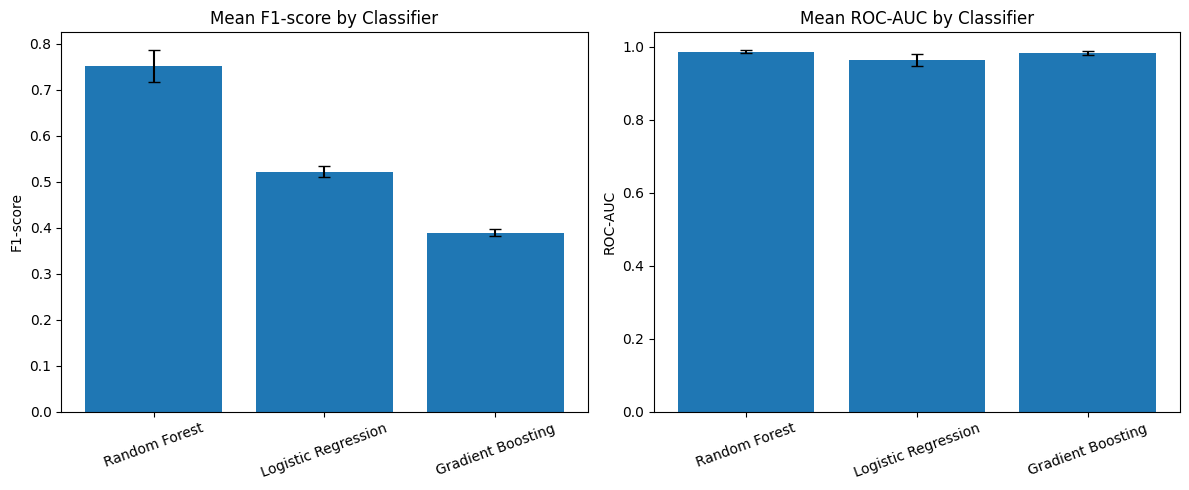

Saved: BA-09_model_comparison.png


In [8]:
# Visual model comparison

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(cv_summary["Model"], cv_summary["F1_Mean"], yerr=cv_summary["F1_SD"], capsize=4)
axes[0].set_title("Mean F1-score by Classifier")
axes[0].set_ylabel("F1-score")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(cv_summary["Model"], cv_summary["ROC_AUC_Mean"], yerr=cv_summary["ROC_AUC_SD"], capsize=4)
axes[1].set_title("Mean ROC-AUC by Classifier")
axes[1].set_ylabel("ROC-AUC")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("BA-09_model_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved: BA-09_model_comparison.png")


In [9]:
# Aggregate confusion matrices across folds

aggregate_cms = {}

for model_name, cms in confusion_matrices.items():
    aggregate = np.sum(cms, axis=0)
    aggregate_cms[model_name] = aggregate

    print(f"\n{model_name}")
    display(pd.DataFrame(
        aggregate,
        index=["Actual neg", "Actual pos"],
        columns=["Predicted neg", "Predicted pos"]
    ))



Logistic Regression


,Predicted neg,Predicted pos
Actual neg,57425,1575
Actual pos,90,910



Random Forest


,Predicted neg,Predicted pos
Actual neg,58914,86
Actual pos,345,655



Gradient Boosting


,Predicted neg,Predicted pos
Actual neg,56026,2974
Actual pos,40,960


## 4. Comparison decision rule

No model is declared the winner in advance. The comparison should consider mean F1-score, Recall, Precision, ROC-AUC, and variability across folds. Because the target is highly imbalanced, these measures are emphasized rather than accuracy alone.

Threshold optimization is intentionally reserved for BA-10.


In [11]:
# Identify leaders under the comparison metrics

leader_f1 = cv_summary.sort_values("F1_Mean", ascending=False).iloc[0]
leader_auc = cv_summary.sort_values("ROC_AUC_Mean", ascending=False).iloc[0]
leader_recall = cv_summary.sort_values("Recall_Mean", ascending=False).iloc[0]
leader_precision = cv_summary.sort_values("Precision_Mean", ascending=False).iloc[0]

print("Highest mean F1-score:", leader_f1["Model"], f"({leader_f1['F1_Mean']:.4f})")
print("Highest mean ROC-AUC:", leader_auc["Model"], f"({leader_auc['ROC_AUC_Mean']:.4f})")
print("Highest mean Recall:", leader_recall["Model"], f"({leader_recall['Recall_Mean']:.4f})")
print("Highest mean Precision:", leader_precision["Model"], f"({leader_precision['Precision_Mean']:.4f})")


Highest mean F1-score: Random Forest (0.7517)
Highest mean ROC-AUC: Random Forest (0.9863)
Highest mean Recall: Gradient Boosting (0.9600)
Highest mean Precision: Random Forest (0.8838)


In [12]:
# Save quantitative evidence

fold_results_df.to_csv("BA-09_fold_level_results.csv", index=False)
cv_summary.to_csv("BA-09_model_comparison_summary.csv", index=False)

cm_rows = []
for model_name, cm in aggregate_cms.items():
    cm_rows.append({
        "Model": model_name,
        "True_Negatives": int(cm[0, 0]),
        "False_Positives": int(cm[0, 1]),
        "False_Negatives": int(cm[1, 0]),
        "True_Positives": int(cm[1, 1]),
    })

pd.DataFrame(cm_rows).to_csv(
    "BA-09_aggregated_confusion_matrices.csv",
    index=False
)

print("Saved BA-09 quantitative reports.")


Saved BA-09 quantitative reports.


In [13]:
# Save run configuration

config = {
    "ticket": "BA-09",
    "cv": "StratifiedKFold",
    "n_splits": N_SPLITS,
    "shuffle": True,
    "random_state": RANDOM_STATE,
    "baseline_threshold": BASELINE_THRESHOLD,
    "test_set_used": False,
    "threshold_tuning": False,
    "feature_count": int(X_train.shape[1]),
    "models": {
        "Logistic Regression": {
            "class_weight": "balanced",
            "solver": "lbfgs",
            "max_iter": 500
        },
        "Random Forest": {
            "n_estimators": 150,
            "class_weight": "balanced_subsample",
            "min_samples_leaf": 2,
            "random_state": RANDOM_STATE,
            "n_jobs": -1
        },
        "Gradient Boosting": {
            "n_estimators": 75,
            "learning_rate": 0.05,
            "max_depth": 2,
            "subsample": 0.8,
            "balanced_sample_weight": True,
            "random_state": RANDOM_STATE
        }
    }
}

with open("BA-09_run_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("Saved: BA-09_run_config.json")


Saved: BA-09_run_config.json


In [14]:
# Create an automatic BA-09 report populated with actual results

leader = cv_summary.sort_values("F1_Mean", ascending=False).iloc[0]
leader_model = leader["Model"]
leader_f1 = float(leader["F1_Mean"])

comparison_table = cv_summary.to_string(index=False)

report = (
    "# BA-09 Classifier Comparison Report\n\n"
    "## Purpose\n"
    "Compare Logistic Regression, Random Forest and Gradient Boosting using five-fold "
    "stratified cross-validation on the prepared UCI APS training data.\n\n"
    "## Experimental controls\n"
    f"- Final feature count: {X_train.shape[1]}\n"
    f"- Cross-validation: StratifiedKFold, {N_SPLITS} folds, shuffled, random state {RANDOM_STATE}\n"
    "- Official test set used for selection/tuning: No\n"
    f"- Baseline threshold: {BASELINE_THRESHOLD}\n"
    "- Threshold tuning: No; reserved for BA-10\n\n"
    "## Cross-validation summary\n\n"
    "```\n"
    + comparison_table
    + "\n```\n\n"
    "## Provisional comparison result\n"
    f"The classifier with the highest mean F1-score in this run is **{leader_model}** "
    f"with mean F1-score **{leader_f1:.4f}**.\n\n"
    "This is a comparison-stage result only. Final model and threshold decisions should "
    "also consider recall, precision, ROC-AUC, stability across folds, and the business "
    "cost of false negatives versus false positives.\n\n"
    "## Scope limitation\n"
    "The UCI APS dataset is a public proxy for the CGSL project. These results demonstrate "
    "analytical methodology and should not be interpreted as direct evidence of CGSL vessel "
    "or equipment performance.\n"
)

with open("BA-09_model_comparison_report.md", "w", encoding="utf-8") as f:
    f.write(report)

print("Saved: BA-09_model_comparison_report.md")
print("Provisional highest mean F1 model:", leader_model)


Saved: BA-09_model_comparison_report.md
Provisional highest mean F1 model: Random Forest


In [15]:
# Final BA-09 artifact inventory

artifact_files = [
    "BA-09_fold_level_results.csv",
    "BA-09_model_comparison_summary.csv",
    "BA-09_aggregated_confusion_matrices.csv",
    "BA-09_model_comparison.png",
    "BA-09_run_config.json",
    "BA-09_model_comparison_report.md",
]

print("BA-09 artifact inventory:")
for name in artifact_files:
    print(f"- {name}: {'READY' if os.path.exists(name) else 'MISSING'}")


BA-09 artifact inventory:
- BA-09_fold_level_results.csv: READY
- BA-09_model_comparison_summary.csv: READY
- BA-09_aggregated_confusion_matrices.csv: READY
- BA-09_model_comparison.png: READY
- BA-09_run_config.json: READY
- BA-09_model_comparison_report.md: READY


In [16]:
# Create one downloadable BA-09 artifact bundle

from google.colab import files
import zipfile

artifact_files = [
    "BA-09_fold_level_results.csv",
    "BA-09_model_comparison_summary.csv",
    "BA-09_aggregated_confusion_matrices.csv",
    "BA-09_model_comparison.png",
    "BA-09_run_config.json",
    "BA-09_model_comparison_report.md",
]

missing = [f for f in artifact_files if not os.path.exists(f)]
if missing:
    raise FileNotFoundError(f"Missing artifacts: {missing}")

zip_name = "BA-09_artifacts.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as z:
    for f in artifact_files:
        z.write(f)

print(f"Created {zip_name}")
files.download(zip_name)


Created BA-09_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>